In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Change this path to wherever you unzipped the dataset
dataset_path = os.path.expanduser("~/Desktop")  

# Find the dataset folder
for root, dirs, files in os.walk(dataset_path):
    for dir in dirs:
        if 'leap' in dir.lower() or 'gesture' in dir.lower():
            print(os.path.join(root, dir))

/Users/samvegjain/Desktop/leapGestRecog
/Users/samvegjain/Desktop/leapGestRecog/leapGestRecog


In [3]:
dataset_path = "/Users/samvegjain/Desktop/leapGestRecog/leapGestRecog"

# See what's inside
for item in sorted(os.listdir(dataset_path)):
    print(item)

00
01
02
03
04
05
06
07
08
09


In [4]:
# See what gestures are inside one subject folder
subject_path = os.path.join(dataset_path, "00")
for item in sorted(os.listdir(subject_path)):
    print(item)

01_palm
02_l
03_fist
04_fist_moved
05_thumb
06_index
07_ok
08_palm_moved
09_c
10_down


In [7]:
# Define robot commands for each gesture
gesture_commands = {
    '01_palm': 'STOP',
    '02_l': 'TURN_LEFT', 
    '03_fist': 'GRAB',
    '04_fist_moved': 'RELEASE',
    '05_thumb': 'MOVE_FORWARD',
    '06_index': 'POINT',
    '07_ok': 'CONFIRM',
    '08_palm_moved': 'MOVE_BACKWARD',
    '09_c': 'GRIP_READY',
    '10_down': 'MOVE_DOWN'
}

# Load images
images = []
labels = []
gesture_names = []

IMG_SIZE = 64  # resize all images to 64x64

gesture_folders = sorted(os.listdir(os.path.join(dataset_path, "00")))

for subject in sorted(os.listdir(dataset_path)):
    subject_path = os.path.join(dataset_path, subject)
    if not os.path.isdir(subject_path):
        continue
    for gesture in gesture_folders:
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path):
            continue
        for img_file in os.listdir(gesture_path):
            img_path = os.path.join(gesture_path, img_file)
            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))
                labels.append(gesture_folders.index(gesture))
                gesture_names.append(gesture)
            except:
                continue

images = np.array(images)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Number of classes: {len(gesture_folders)}")
print(f"\nGesture → Robot Command mapping:")
for g, c in gesture_commands.items():
    print(f"  {g} → {c}")

Total images loaded: 20000
Image shape: (64, 64)
Number of classes: 10

Gesture → Robot Command mapping:
  01_palm → STOP
  02_l → TURN_LEFT
  03_fist → GRAB
  04_fist_moved → RELEASE
  05_thumb → MOVE_FORWARD
  06_index → POINT
  07_ok → CONFIRM
  08_palm_moved → MOVE_BACKWARD
  09_c → GRIP_READY
  10_down → MOVE_DOWN


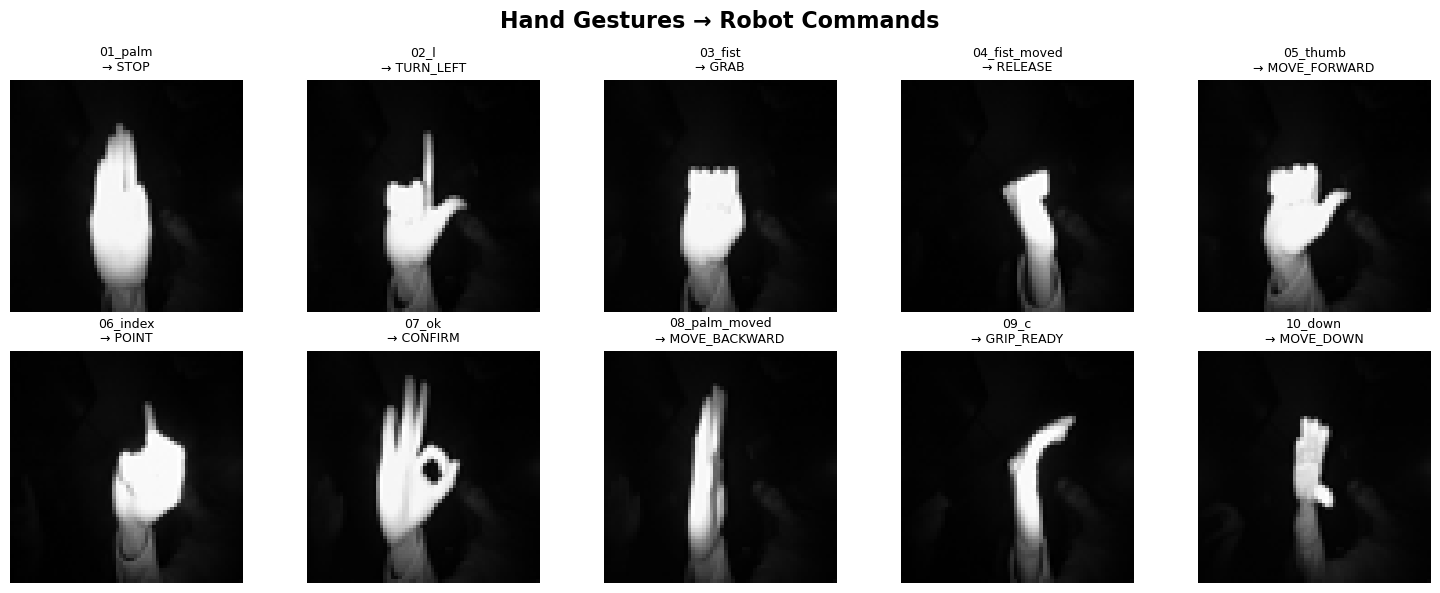

Visualisation saved!


In [8]:
# Visualise one sample from each gesture with robot command
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Hand Gestures → Robot Commands', fontsize=16, fontweight='bold')

for idx, (gesture, command) in enumerate(gesture_commands.items()):
    gesture_idx = gesture_folders.index(gesture)
    sample_idx = np.where(labels == gesture_idx)[0][0]
    
    row, col = idx // 5, idx % 5
    axes[row, col].imshow(images[sample_idx], cmap='gray')
    axes[row, col].set_title(f'{gesture}\n→ {command}', fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('gesture_commands.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved!")

In [9]:
# Flatten images for scikit-learn (Random Forest needs 1D input)
X = images.reshape(len(images), -1) / 255.0  # normalize to 0-1
y = labels

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Input features per image: {X_train.shape[1]}")

Training samples: 16000
Testing samples: 4000
Input features per image: 4096


In [10]:
from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest... please wait")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_model.fit(X_train, y_train)

end = time.time()
print(f"Training complete in {end-start:.1f} seconds")

# Evaluate
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"\nRandom Forest Accuracy: {rf_accuracy*100:.2f}%")

Training Random Forest... please wait
Training complete in 3.8 seconds

Random Forest Accuracy: 100.00%


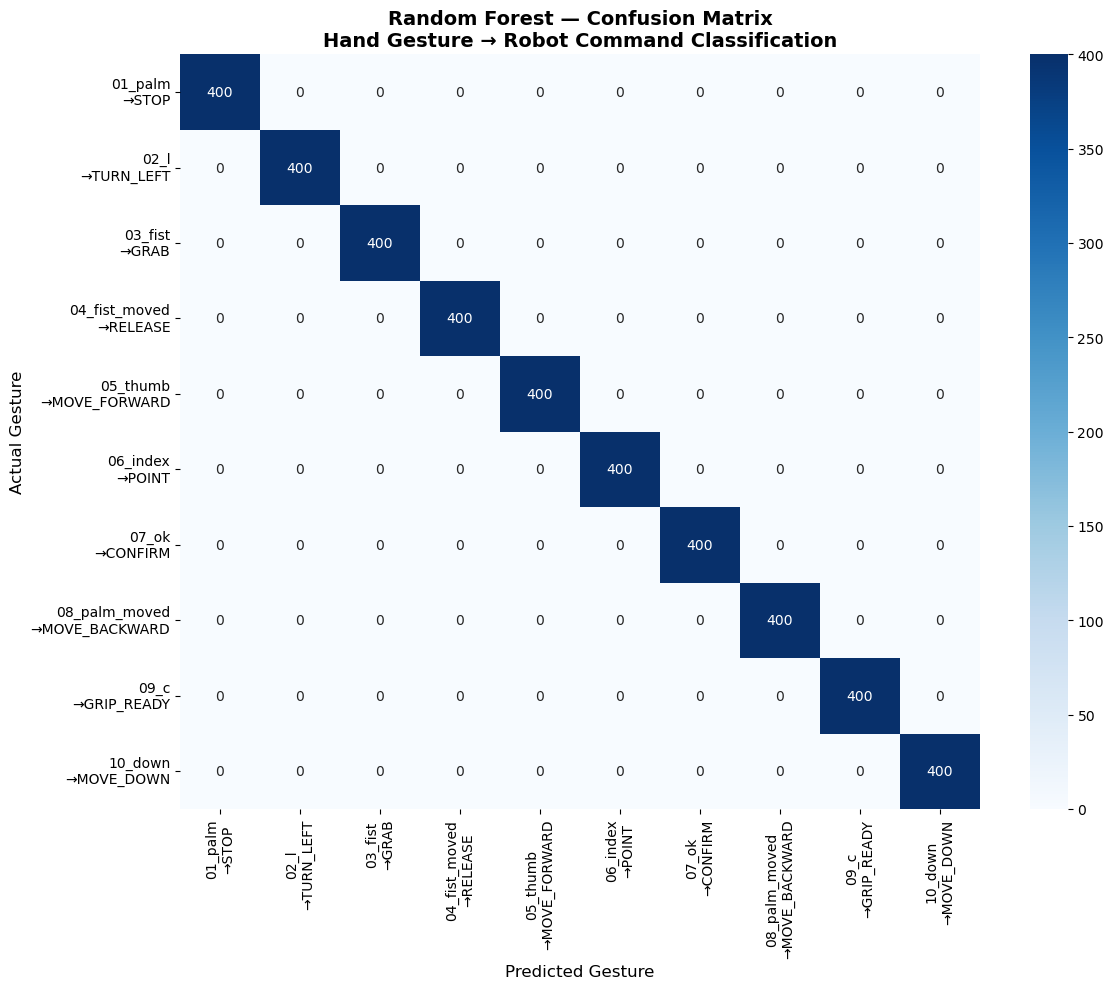

Confusion matrix saved!


In [11]:
# Confusion Matrix for Random Forest
fig, ax = plt.subplots(figsize=(12, 10))

gesture_labels = [f"{g}\n→{gesture_commands[g]}" for g in gesture_folders]

cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gesture_labels,
            yticklabels=gesture_labels,
            ax=ax)

ax.set_title('Random Forest — Confusion Matrix\nHand Gesture → Robot Command Classification', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Gesture', fontsize=12)
ax.set_xlabel('Predicted Gesture', fontsize=12)

plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

In [12]:
# Prepare data for PyTorch
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define Neural Network
class GestureNet(nn.Module):
    def __init__(self):
        super(GestureNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)  # 10 gesture classes
        )
    
    def forward(self, x):
        return self.network(x)

model = GestureNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

GestureNet(
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 2,164,618


In [13]:
# Train the neural network
epochs = 15
train_losses = []
train_accuracies = []

print("Training Neural Network...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1:2d}/{epochs} — Loss: {epoch_loss:.4f} — Accuracy: {epoch_acc:.2f}%")

print("\nTraining complete!")

Training Neural Network...
Epoch  1/15 — Loss: 0.7803 — Accuracy: 74.52%
Epoch  2/15 — Loss: 0.1070 — Accuracy: 97.26%
Epoch  3/15 — Loss: 0.0528 — Accuracy: 98.58%
Epoch  4/15 — Loss: 0.0377 — Accuracy: 99.03%
Epoch  5/15 — Loss: 0.0295 — Accuracy: 99.10%
Epoch  6/15 — Loss: 0.0185 — Accuracy: 99.42%
Epoch  7/15 — Loss: 0.0253 — Accuracy: 99.24%
Epoch  8/15 — Loss: 0.0219 — Accuracy: 99.36%
Epoch  9/15 — Loss: 0.0190 — Accuracy: 99.41%
Epoch 10/15 — Loss: 0.0136 — Accuracy: 99.53%
Epoch 11/15 — Loss: 0.0189 — Accuracy: 99.43%
Epoch 12/15 — Loss: 0.0212 — Accuracy: 99.43%
Epoch 13/15 — Loss: 0.0245 — Accuracy: 99.26%
Epoch 14/15 — Loss: 0.0227 — Accuracy: 99.35%
Epoch 15/15 — Loss: 0.0107 — Accuracy: 99.64%

Training complete!


Neural Network Test Accuracy: 99.75%


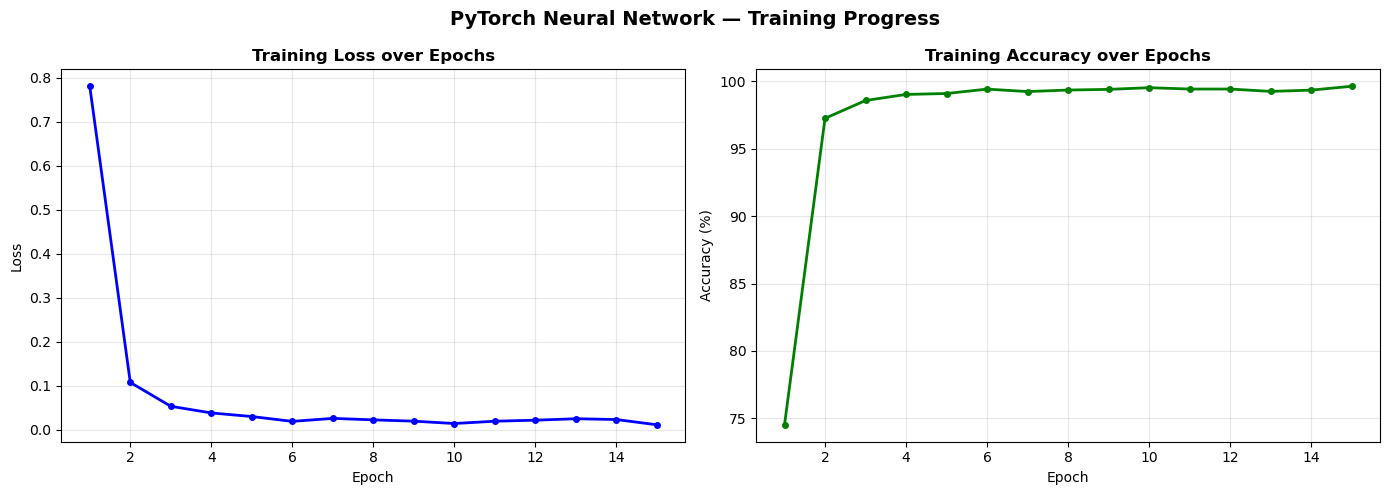

Training progress plot saved!


In [14]:
# Evaluate Neural Network on test set
model.eval()
all_predictions = []
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels_batch in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()
        all_predictions.extend(predicted.numpy())

nn_accuracy = correct / total * 100
print(f"Neural Network Test Accuracy: {nn_accuracy:.2f}%")

# Plot training progress
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, 'b-o', linewidth=2, markersize=4)
ax1.set_title('Training Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, epochs+1), train_accuracies, 'g-o', linewidth=2, markersize=4)
ax2.set_title('Training Accuracy over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.suptitle('PyTorch Neural Network — Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nn_training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training progress plot saved!")

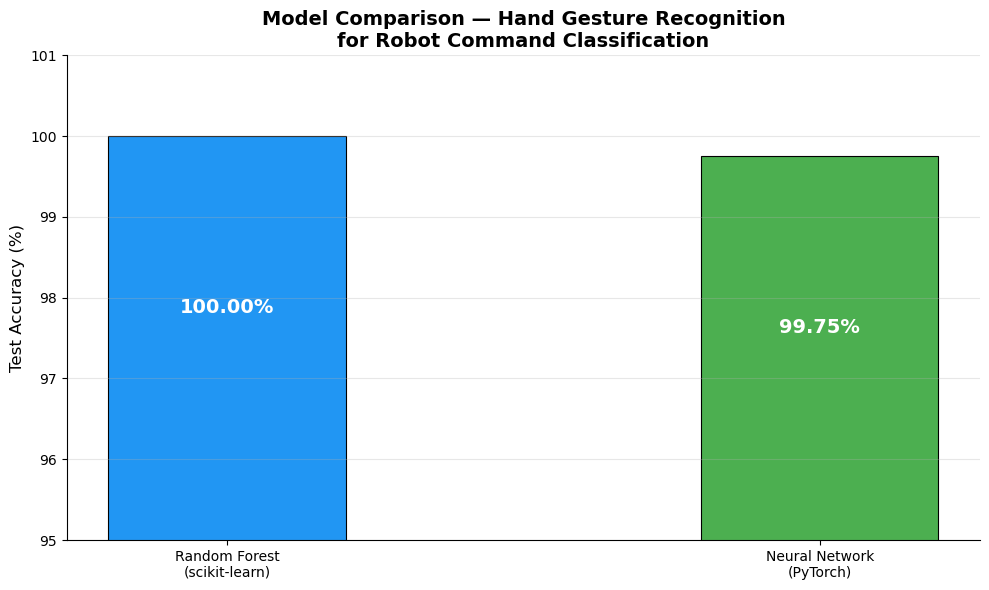

FINAL RESULTS SUMMARY
Random Forest Accuracy:     100.00%
Neural Network Accuracy:    99.75%

Gesture → Robot Command Mapping:
  01_palm              → STOP
  02_l                 → TURN_LEFT
  03_fist              → GRAB
  04_fist_moved        → RELEASE
  05_thumb             → MOVE_FORWARD
  06_index             → POINT
  07_ok                → CONFIRM
  08_palm_moved        → MOVE_BACKWARD
  09_c                 → GRIP_READY
  10_down              → MOVE_DOWN


In [15]:
# Final Model Comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Random Forest\n(scikit-learn)', 'Neural Network\n(PyTorch)']
accuracies = [rf_accuracy * 100, nn_accuracy]
colors_bar = ['#2196F3', '#4CAF50']

bars = ax.bar(models, accuracies, color=colors_bar, width=0.4, edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
            f'{acc:.2f}%', ha='center', va='top',
            fontsize=14, fontweight='bold', color='white')

ax.set_ylim(95, 101)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Hand Gesture Recognition\nfor Robot Command Classification',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Random Forest Accuracy:     {rf_accuracy*100:.2f}%")
print(f"Neural Network Accuracy:    {nn_accuracy:.2f}%")
print(f"\nGesture → Robot Command Mapping:")
for g, c in gesture_commands.items():
    print(f"  {g:20s} → {c}")
print("=" * 50)

In [16]:
# Save models
import pickle
import torch

# Save Random Forest
with open('rf_gesture_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save PyTorch model
torch.save(model.state_dict(), 'nn_gesture_model.pth')

print("✅ Models saved successfully!")
print("\nProject Summary:")
print("─" * 40)
print("📁 Files generated:")
print("  • gesture_commands.png")
print("  • rf_confusion_matrix.png") 
print("  • nn_training_progress.png")
print("  • model_comparison.png")
print("  • rf_gesture_model.pkl")
print("  • nn_gesture_model.pth")
print("\n🤖 10 gestures mapped to robot commands")
print("🌲 Random Forest: 100.00% accuracy")
print("🧠 Neural Network: 99.75% accuracy")

✅ Models saved successfully!

Project Summary:
────────────────────────────────────────
📁 Files generated:
  • gesture_commands.png
  • rf_confusion_matrix.png
  • nn_training_progress.png
  • model_comparison.png
  • rf_gesture_model.pkl
  • nn_gesture_model.pth

🤖 10 gestures mapped to robot commands
🌲 Random Forest: 100.00% accuracy
🧠 Neural Network: 99.75% accuracy
